In [1]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

exp_path = NOTEBOOK_DIR / 'logs'
base_scores = pl.read_csv(PROJECT_ROOT / 'experiments' / 'base_tables' / 'base_simple_scores.csv').rename({'': 'table'})
aug_scores = pl.read_csv(exp_path / 'simple_results.csv').rename({'': 'experiment'})

exp_dir = os.listdir(exp_path)
runtime_res = {}
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    df = pl.from_records(lines, orient='col')
    runtime = df.select(pl.col('runtime').sum()).to_series()[0]
    runtime_res[exp] = runtime
runtime_df = pl.from_dicts([{'experiment': k, 'runtime': v} for k, v in runtime_res.items()])
aug_scores = aug_scores.join(runtime_df, left_on='experiment', right_on='experiment', how='left')
aug_scores = aug_scores.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'k']).struct.unnest()
)
aug_scores = aug_scores.join(base_scores, on='table', how='left', suffix='_base')

aug_scores = aug_scores.with_columns((pl.col('rmse_base').fill_null(0) + pl.col('f1_weighted_base').fill_null(0)).round(3).alias('score_base'))
aug_scores = aug_scores.with_columns((pl.col('rmse').fill_null(0) + pl.col('f1_weighted').fill_null(0)).round(3).alias('score'))
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('rmse').is_not_null())
    .then(pl.lit('rmse'))
    .otherwise(pl.lit('f1'))
    .alias('metric')
)
# Create base rows for each unique (lake, table) combination
base_rows = (
    aug_scores
    .unique(subset=['lake', 'table'])
    .with_columns([
        pl.lit('base').alias('algorithm'),
        pl.col('score_base').alias('score'),
        pl.col('rmse_base').alias('rmse'),
        pl.col('f1_weighted_base').alias('f1'),
        pl.lit(0.0).alias('runtime'),
        (pl.col('lake') + '_' + pl.col('table') + '_base').alias('experiment')
    ])
    .select(aug_scores.columns)
)
aug_scores = pl.concat([aug_scores, base_rows])
aug_scores = aug_scores.with_columns(
    pl.when(pl.col('table') == 'pageviews')
    .then((pl.col('score')/1e6).round(3))
    .otherwise(pl.col('score'))
    .alias('score')
)

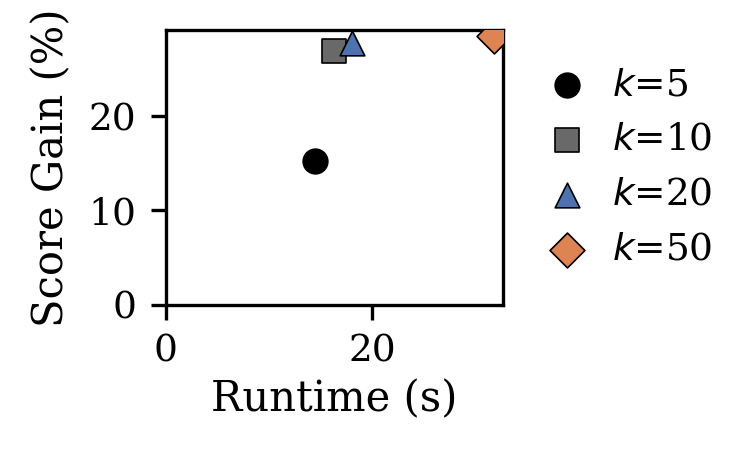

In [2]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

# Filter out base rows
data = aug_scores.filter(pl.col('k') != 'base')

# Relative improvement (direction-aware)
data = data.with_columns(
    pl.when(pl.col('metric') == 'rmse')
    .then((pl.col('score_base') - pl.col('score')) / pl.col('score_base'))
    .otherwise((pl.col('score') - pl.col('score_base')) / pl.col('score_base'))
    .alias('rel_improvement')
)

# Aggregate across tables per k
agg = data.group_by('k').agg([
    pl.col('rel_improvement').mean().alias('mean_improvement'),
    pl.col('runtime').mean().alias('mean_runtime'),
]).with_columns(pl.col('k').cast(pl.Int32)).sort('k')

markers = {5: 'o', 10: 's', 20: '^', 50: 'D'}
colors = {5: 'black', 10: 'dimgray', 20: '#4c72b0', 50: '#dd8452'}

fig, ax = plt.subplots(figsize=(2.4, 1.4))
for row in agg.iter_rows(named=True):
    k = row['k']
    ax.scatter(row['mean_runtime'], row['mean_improvement'] * 100,
               marker=markers.get(k, 'o'), color=colors.get(k, 'black'),
               label=f'$k$={k}', s=35, zorder=3, edgecolors='black', linewidths=0.4)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Runtime (s)', labelpad=2)
ax.set_ylabel('Score Gain (%)')
ax.legend(ncol=1, columnspacing=0.6, handletextpad=0.2, borderpad=0.2,
          loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(pad=0.3)
plt.savefig(PAPER_ROOT / 'figures' / 'top_k_ablation.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [3]:
# Generate TikZ scatter plot
data = aug_scores.filter(pl.col('k') != 'base')
data = data.with_columns(
    pl.when(pl.col('metric') == 'rmse')
    .then((pl.col('score_base') - pl.col('score')) / pl.col('score_base'))
    .otherwise((pl.col('score') - pl.col('score_base')) / pl.col('score_base'))
    .alias('rel_improvement')
)
agg = data.group_by('k').agg([
    pl.col('rel_improvement').mean().alias('mean_improvement'),
    pl.col('runtime').mean().alias('mean_runtime'),
]).with_columns(pl.col('k').cast(pl.Int32)).sort('k')

# Use filled mark variants (mark=* means filled circle, square* = filled square, etc.)
marker_map = {5: '*', 10: 'square*', 20: 'triangle*', 50: 'diamond*'}
# Define colors by name + RGB tuple so we can emit \definecolor
color_defs = {
    5:  ('plotblue',   '31,119,180'),
    10: ('plotorange', '255,127,14'),
    20: ('plotgreen',  '44,160,44'),
    50: ('plotred',    '214,39,40'),
}

tikz = []
# Emit \definecolor before tikzpicture
for k_val in sorted(color_defs):
    name, rgb = color_defs[k_val]
    tikz.append(f"\\definecolor{{{name}}}{{RGB}}{{{rgb}}}")

tikz += [
    r"\begin{tikzpicture}",
    r"\begin{axis}[",
    r"  width=2.4in,",
    r"  height=1.4in,",
    r"  xlabel={Runtime (s)},",
    r"  ylabel={Score Gain (\%)},",
    r"  xmin=0,",
    r"  ymin=0,",
    r"  x label style={font=\small},",
    r"  y label style={font=\small},",
    r"  x tick label style={font=\small},",
    r"  y tick label style={font=\small},",
    r"  legend style={font=\small, at={(1.02,0.5)}, anchor=west, draw=none},",
    r"  axis lines=left,",
    r"  clip=false,",
    r"]",
]

for row in agg.iter_rows(named=True):
    k = row['k']
    x = row['mean_runtime']
    y = row['mean_improvement'] * 100
    mk = marker_map[k]
    cname = color_defs[k][0]
    tikz.append(f"\\addplot[only marks, mark={mk}, mark size=2.5pt, {cname}, mark options={{draw=black, line width=0.4pt}}]")
    tikz.append(f"  coordinates {{({x:.1f},{y:.1f})}};")
    tikz.append(f"\\addlegendentry{{$k$={k}}}")

tikz.append(r"\end{axis}")
tikz.append(r"\end{tikzpicture}")

tikz_code = "\n".join(tikz)
out_path = PAPER_ROOT / 'figures' / 'top_k_ablation.tex'
out_path.write_text(tikz_code)
print(f"Written to {out_path}")

Written to /home/fedor/Matryoshka/figures/top_k_ablation.tex
